# 02 - Time-Aware Evaluation Framework and Sanity Check

**Goal:** build the *ruler* that every later experiment is measured with, and check that the ruler works.
No model is tuned here: every model uses scikit-learn **default settings** (`random_state=42`).

> **Beginner note - why not just split randomly?**
> Notebook 01 showed that the sensor readings reveal which batch (time period) a sample came from (99% accuracy).
> A random split therefore puts near-identical "twin" samples in both the training and the test set, and the model
> looks brilliant. In real use the model must predict *future* data, so we **train on the past and test on the future**.

## The three protocols
| Protocol | Training batches | Test batches | Meaning |
|---|---|---|---|
| **P1** | 1-3 | 4, 5, ..., 10 (each scored separately) | the protocol on our PPT slide |
| **P2** | 1 | 2, 3, ..., 10 | strongest drift: oldest model against everything (Vergara et al., setting 1) |
| **P3** | 1 .. k-1 | k = 2, ..., 10 | rolling: always train on everything older than the test batch (Vergara et al., setting 2) |

Each test batch is scored **separately**, so we can see performance fall as the gap between training and test grows.

## Metrics
* **Accuracy** - share of correct predictions.
* **Macro precision / recall / F1** - computed per gas, then averaged so every gas counts equally
  (important because some gases are rare in some batches). **Macro-F1 is our main metric.**
  Averages use only gases actually present in the test batch (some batches have no Toluene).

## Leakage safety
Each model is a `Pipeline`: *StandardScaler -> (optional PCA or LDA) -> classifier*, cloned and fitted on the **training
batches only**. The scaler/PCA/LDA never see test data. `tests/test_evaluate.py` checks this automatically.

In [1]:
import os, sys, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from src.data import load_all
from src.evaluate import (evaluate_protocol, random_split_baseline, summarize, protocol_splits,
                          PROTOCOL_DESCRIPTIONS)
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS
apply_style()
FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True); RES = ROOT / "results"
X, y, batch = load_all()
print(X.shape)

(13910, 128)


## 1. The protocols, drawn

Blue = training batches, orange = the test batch being scored, grey = not used. P1 and P2 repeat for every test batch;
for P3 we draw one example (k = 6).

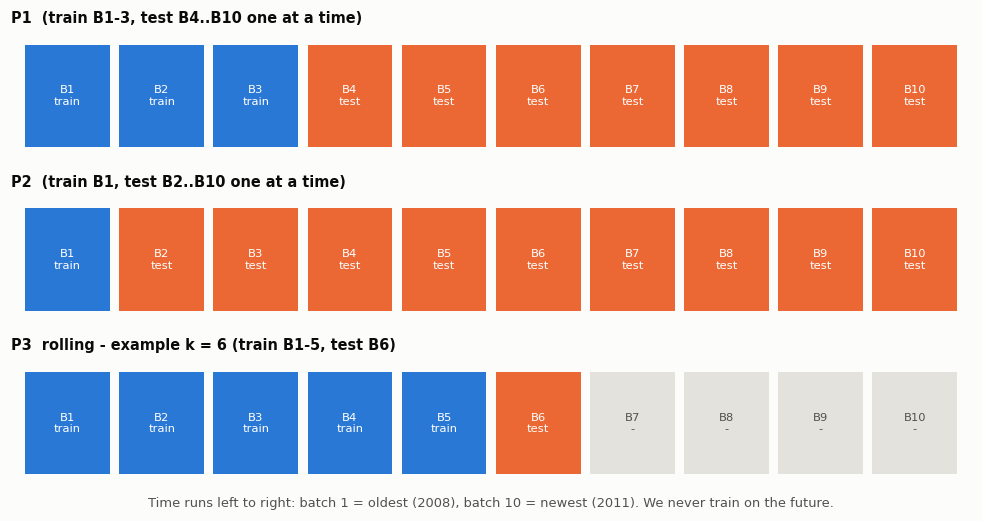

In [2]:
TRAIN, TEST, OFF = "#2a78d6", "#eb6834", "#e3e2dd"
panels = [("P1  (train B1-3, test B4..B10 one at a time)", (1, 2, 3), [4, 5, 6, 7, 8, 9, 10]),
          ("P2  (train B1, test B2..B10 one at a time)", (1,), list(range(2, 11))),
          ("P3  rolling - example k = 6 (train B1-5, test B6)", (1, 2, 3, 4, 5), [6])]
fig, axes = plt.subplots(3, 1, figsize=(9, 4.6))
for ax, (title, tr, te) in zip(axes, panels):
    for b in range(1, 11):
        role = "train" if b in tr else ("test" if b in te else "-")
        col = TRAIN if role == "train" else TEST if role == "test" else OFF
        ax.add_patch(Rectangle((b - 0.45, 0.1), 0.9, 0.8, facecolor=col, edgecolor="none"))
        ax.text(b, 0.5, f"B{b}\n{role}", ha="center", va="center", fontsize=7.5,
                color="white" if role != "-" else INK2)
    ax.set_xlim(0.4, 10.6); ax.set_ylim(0, 1); ax.set_yticks([]); ax.set_xticks([]); ax.grid(False)
    ax.set_title(title, loc="left", fontsize=9.5)
    for s in ax.spines.values(): s.set_visible(False)
fig.text(0.5, -0.01, "Time runs left to right: batch 1 = oldest (2008), batch 10 = newest (2011). We never train on the future.",
         ha="center", fontsize=8.5, color=INK2)
fig.tight_layout(); fig.savefig(FIG / "08_protocols.png"); plt.show()

## 2. Sanity check with default SVM and kNN

* **SVM (RBF kernel)** and **kNN (k = 5)** with scikit-learn defaults and scaling only (`variant="raw"`).
* Run under P1, P2 and P3, plus the **misleading random split** (70/30, stratified) as a reference.
* These are *preliminary, untuned* numbers. The full model comparison is Step 4.

In [3]:
models = {"SVM": SVC(), "kNN": KNeighborsClassifier()}
parts = []
for name, est in models.items():
    for proto in ["P1", "P2", "P3"]:
        parts.append(evaluate_protocol(est, X, y, batch, proto, "raw", name=name))
    parts.append(random_split_baseline(est, X, y, "raw", name=name))
res = pd.concat(parts, ignore_index=True)
res.to_csv(RES / "02_sanity_check.csv", index=False)
summ = summarize(res); summ.to_csv(RES / "02_sanity_summary.csv", index=False)
display(summ.round(3))

,model,variant,protocol,n_test_batches,mean_accuracy,mean_macro_f1,weighted_accuracy,weighted_macro_f1,min_macro_f1
0,SVM,raw,P1,7.0,0.705,0.690,0.608,0.579,0.431
1,SVM,raw,P2,9.0,0.390,0.316,0.411,0.331,0.213
2,SVM,raw,P3,9.0,0.824,0.797,0.778,0.750,0.632
3,SVM,raw,random,1.0,0.977,0.976,0.977,0.976,0.976
4,kNN,raw,P1,7.0,0.615,0.609,0.581,0.558,0.464
5,kNN,raw,P2,9.0,0.365,0.303,0.395,0.330,0.126
6,kNN,raw,P3,9.0,0.785,0.766,0.739,0.711,0.548
7,kNN,raw,random,1.0,0.990,0.990,0.990,0.990,0.990


**How to read the table.**
`mean_*` = simple average over test batches (each batch counts equally);
`weighted_*` = average weighted by test-batch size (each sample counts equally; batches 6, 7 and 10 dominate);
`min_macro_f1` = the worst batch. The `random` row is the score from the leaky random split.

In [4]:
p1 = res[res.protocol == "P1"].pivot(index="test_batch", columns="model", values=["accuracy", "macro_f1"]).round(3)
p1.columns = [f"{m} {k}" for k, m in p1.columns]; display(p1)

,SVM accuracy,kNN accuracy,SVM macro_f1,kNN macro_f1
test_batch,,,,
4,0.876,0.727,0.905,0.755
5,0.954,0.756,0.955,0.796
6,0.697,0.630,0.621,0.587
7,0.684,0.621,0.648,0.591
8,0.551,0.449,0.543,0.464
9,0.743,0.621,0.724,0.579
10,0.431,0.499,0.431,0.489


## 3. Random split vs time-aware split (the central picture of the project)

Lines = score on each test batch. The **dashed horizontal line** is what a random split would have told us.
The gap between the dashed line and the dots is the part of the accuracy that was only an illusion.

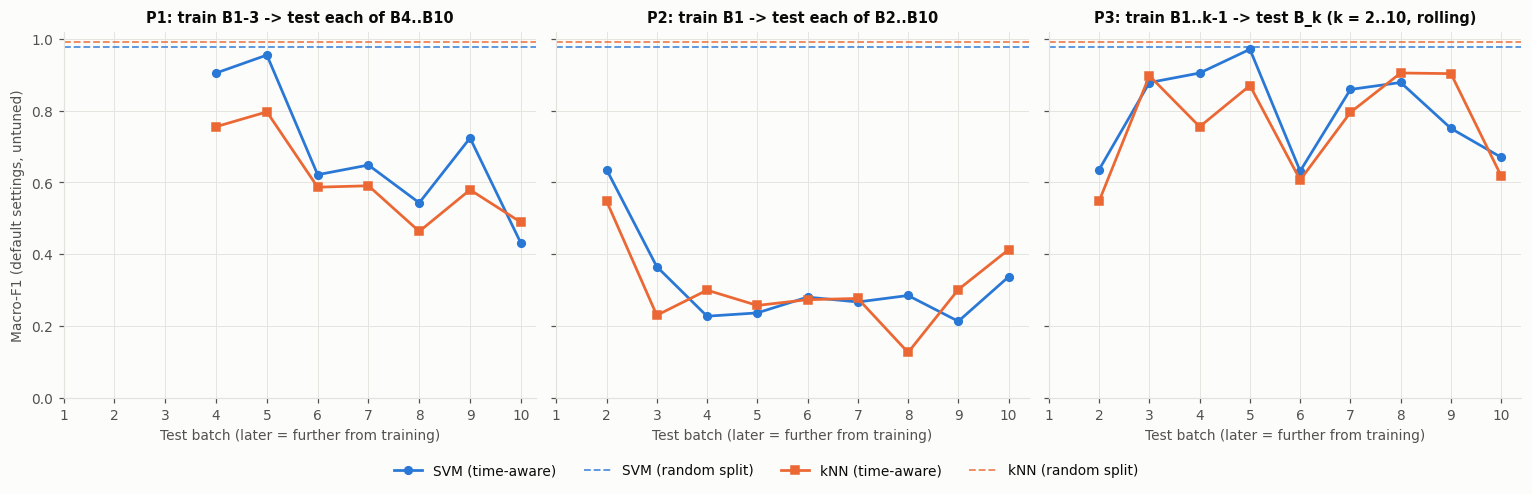

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
colors = {"SVM": SERIES[0], "kNN": SERIES[1]}; marks = {"SVM": MARKERS[0], "kNN": MARKERS[1]}
for ax, proto in zip(axes, ["P1", "P2", "P3"]):
    for name in models:
        d = res[(res.model == name) & (res.protocol == proto)]
        rnd = res[(res.model == name) & (res.protocol == "random")]["macro_f1"].iloc[0]
        ax.plot(d.test_batch, d.macro_f1, color=colors[name], marker=marks[name], ms=5, lw=1.8, label=f"{name} (time-aware)")
        ax.axhline(rnd, color=colors[name], ls="--", lw=1.2, alpha=0.8, label=f"{name} (random split)")
    ax.set_title(f"{proto}: {PROTOCOL_DESCRIPTIONS[proto]}", fontsize=9.5)
    ax.set_xlabel("Test batch (later = further from training)"); ax.set_xticks(range(1, 11)); ax.set_ylim(0, 1.02)
axes[0].set_ylabel("Macro-F1 (default settings, untuned)")
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.07))
fig.tight_layout(); fig.savefig(FIG / "09_time_vs_random_sanity.png"); plt.show()

## 4. Framework smoke test: PCA and LDA variants

Just to prove the `PCA` and `LDA` variants run end-to-end under the same rules (default SVM, protocol P1).
These numbers are **not** analysed here; Step 3 studies PCA and LDA properly.

In [6]:
smoke = pd.concat([evaluate_protocol(SVC(), X, y, batch, "P1", v, name="SVM") for v in ["raw", "PCA", "LDA"]], ignore_index=True)
smoke.to_csv(RES / "02_variant_smoke_test.csv", index=False)
display(summarize(smoke).round(3))

,model,variant,protocol,n_test_batches,mean_accuracy,mean_macro_f1,weighted_accuracy,weighted_macro_f1,min_macro_f1
0,SVM,raw,P1,7.0,0.705,0.690,0.608,0.579,0.431
1,SVM,PCA,P1,7.0,0.666,0.660,0.563,0.552,0.450
2,SVM,LDA,P1,7.0,0.666,0.614,0.602,0.556,0.404


## 5. Key takeaways

All numbers below are **untuned, default-setting** models with scaling only; they are a sanity check of the framework, not final results.

| Protocol | SVM accuracy / macro-F1 | kNN accuracy / macro-F1 |
|---|---|---|
| Random split (misleading) | 97.7% / 97.6% | 99.0% / 99.0% |
| **P1** (train B1-3, mean of test B4-10) | **70.5% / 69.0%** | **61.5% / 60.9%** |
| **P2** (train B1, mean of test B2-10) | 39.0% / 31.6% | 36.5% / 30.3% |
| **P3** (rolling, mean of test B2-10) | 82.4% / 79.7% | 78.5% / 76.6% |

1. **The framework works and reproduces the earlier quick check.** Default SVM on P1 gives 87.6, 95.4, 69.7, 68.4, 55.1, 74.3, 43.1% accuracy on batches 4-10, matching the pre-framework numbers (88, 95, 70, 68, 55, 74, 43). 14 automated tests pass (chronological order, scaler fitted on training data only, hand-checked metrics).
2. **A random split overstates performance by about 29-38 macro-F1 points.** SVM: 97.6% (random) vs 69.0% (P1). kNN: 99.0% vs 60.9%. This is the project's central argument in one number.
3. **Performance decays with distance in time.** Under P1, SVM falls from 87.6% accuracy on batch 4 to 43.1% on batch 10. Under P2 (training on batch 1 only), both models collapse to roughly 13-45% accuracy on batches 4-10 (random guessing among 6 gases would give about 17%).
4. **More recent training data helps a lot.** On the *same* test batches (4-10), rolling P3 beats P1 by +12 accuracy points for SVM (82.5% vs 70.5%) and +17 for kNN (78.4% vs 61.5%). Caution: P3 also trains on more samples, so this does not yet separate "newer" from "more" data; the sliding-window experiment in the drift-mitigation step will.
5. **SVM beats kNN on average, but not on every batch.** SVM leads under P1 (70.5% vs 61.5% accuracy), but kNN is ahead on batch 10 (49.9% vs 43.1%). Single-batch differences are noisy, especially on small batches (4, 5, 8), so confidence intervals and significance tests are planned for the final phase.
6. **Weighted scores are lower than simple averages.** Batches 6, 7 and 10 hold most of the samples and are harder than the small batches 4 and 5, so SVM P1 weighted macro-F1 is 57.9% against a simple mean of 69.0%. Both will be reported.
7. **PCA and LDA both run under the same leak-free rules** (smoke test, SVM, P1: raw 70.5%, PCA 66.6%, LDA 66.6% accuracy). Neither helped here; this is not analysed yet and is the subject of the next step.